Model Building and Evaluation

In this stage, different classification algorithms are trained and evaluated to predict movie success categories: Hit, Average, and Flop.

The models are compared using performance metrics such as accuracy, confusion matrix, precision, recall, F1-score, and classification report.

The classification models considered in this project include:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting / XGBoost

The objective is to compare the performance of different classification algorithms and understand their ability to predict movie success.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("cleaned_movie_data.csv")

In [13]:
df.shape

(4998, 28)

In [14]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,classify
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,hit
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,hit
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,hit
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,hit
4,unknown,Doug Walker,110.0,103.0,131.0,369.0,Rob Walker,131.0,25445749.0,Documentary,...,unknown,unknown,unknown,20000000.0,2005.0,12.0,7.1,2.35,0,hit


In [15]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'num_user_for_reviews', 'language', 'country', 'content_rating',
       'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score',
       'aspect_ratio', 'movie_facebook_likes', 'classify'],
      dtype='str')

Applying Selected Features

Based on the correlation and multicollinearity analysis performed during feature engineering, `actor_1_facebook_likes` is removed because it showed a very strong correlation with `cast_total_facebook_likes`.

The IMDb score is excluded from the input features because it was used to create the target variable and including it would cause target leakage. Movie title is also excluded because it acts primarily as an identifier.

In [16]:
df.drop("actor_1_facebook_likes", axis=1, inplace=True)

In [17]:
X = df.drop(["classify","imdb_score","movie_title"], axis=1)
y = df["classify"]

In [18]:
X.shape

(4998, 24)

In [19]:
y.value_counts()

classify
hit        3556
average    1401
flop         41
Name: count, dtype: int64

In [20]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include=["object", "str"]).columns

le = LabelEncoder()

for column in categorical_columns:
    X[column] = le.fit_transform(X[column])

In [21]:
X.dtypes

color                          int64
director_name                  int64
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                   int64
gross                        float64
genres                         int64
actor_1_name                   int64
num_voted_users                int64
cast_total_facebook_likes      int64
actor_3_name                   int64
facenumber_in_poster         float64
plot_keywords                  int64
num_user_for_reviews         float64
language                       int64
country                        int64
content_rating                 int64
budget                       float64
title_year                   float64
actor_2_facebook_likes       float64
aspect_ratio                 float64
movie_facebook_likes           int64
dtype: object

In [22]:
#Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [25]:
X_train.shape, X_test.shape

((3998, 24), (1000, 24))

In [26]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_train_scaled.shape

(3998, 24)

In [28]:
print(X_train.shape)
print(X_test.shape)
print(X_train_scaled.shape)


(3998, 24)
(1000, 24)
(3998, 24)


Training the Logistic Regression Model:

A Logistic Regression classifier is trained using the scaled training dataset. The trained model is then used to predict movie success categories for the unseen test dataset.

In [29]:
from sklearn.linear_model import LogisticRegression


In [30]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [31]:
y_pred_log = log_model.predict(X_test_scaled)

In [32]:
y_pred_log[:10]

array(['hit', 'average', 'hit', 'hit', 'hit', 'average', 'average',
       'average', 'hit', 'hit'], dtype=object)

Logistic Regression Model Evaluation

The performance of the Logistic Regression model is evaluated using accuracy, confusion matrix, and classification report. These metrics help assess how effectively the model predicts Hit, Average, and Flop movie categories on the unseen test dataset.

In [33]:
#Accuracy

from sklearn.metrics import accuracy_score

In [34]:
log_accuracy = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.756


**Observation:** The Logistic Regression model achieved an accuracy of 75.6% on the test dataset. This means that approximately 75.6% of the movie success categories were predicted correctly. However, since the target classes are imbalanced, accuracy alone is not sufficient to evaluate the model. Therefore, the confusion matrix and classification report are also examined.

In [35]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

In [36]:
cm_log = confusion_matrix(y_test, y_pred_log, labels=["hit","average","flop"])

In [37]:
cm_log

array([[654,  57,   1],
       [178, 102,   0],
       [  4,   4,   0]])

**Observation:** The Logistic Regression model correctly classified 654 Hit movies and 102 Average movies. However, it did not correctly classify any of the 8 Flop movies in the test dataset. A large number of Average movies (178) were incorrectly classified as Hit. This indicates that although the model achieved an overall accuracy of 75.6%, its performance varies considerably across the three movie success categories. The very small number of Flop movies in the dataset may contribute to the poor performance for this minority class.

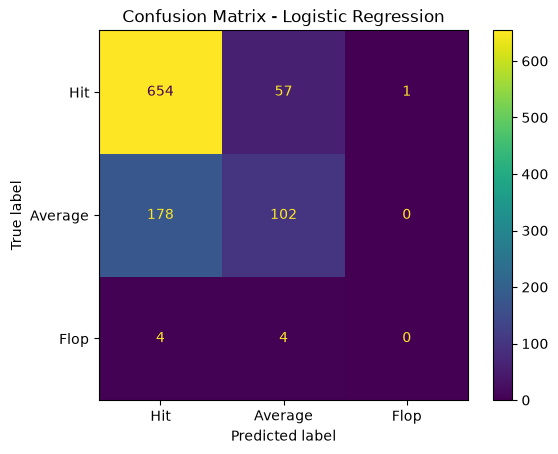

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Hit", "Average", "Flop"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Observation:** The Logistic Regression model correctly predicted 654 Hit movies and 102 Average movies. However, it failed to correctly predict any of the 8 Flop movies. Additionally, 178 Average movies were incorrectly classified as Hit. This shows that although the model achieved an overall accuracy of 75.6%, its performance is much stronger for the Hit category than for the minority Flop category. The class imbalance in the dataset is likely contributing to this difference in performance.

In [39]:
#Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

     average       0.63      0.36      0.46       280
        flop       0.00      0.00      0.00         8
         hit       0.78      0.92      0.84       712

    accuracy                           0.76      1000
   macro avg       0.47      0.43      0.44      1000
weighted avg       0.73      0.76      0.73      1000



Decision Tree Classifier:
Decision Tree is a supervised machine learning algorithm used for classification and regression problems.
The model creates a tree-like structure by repeatedly splitting the data based on features that help separate the target classes.

In [40]:
#Training the Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

In [41]:
dt_model = DecisionTreeClassifier(random_state=42)

In [42]:
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [43]:
y_pred_dt[:10]

array(['hit', 'average', 'hit', 'average', 'hit', 'hit', 'average',
       'average', 'hit', 'average'], dtype=object)

In [44]:
# Decision Tree Model Evaluation

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.719


**Observation:** The Decision Tree Classifier achieved an overall accuracy of 71.9% on the test dataset. This means that approximately 71.9% of the movie success categories were predicted correctly. Since the target classes are imbalanced, accuracy alone is not sufficient to evaluate the model. Therefore, the confusion matrix and classification report are also examined.

In [45]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["hit", "average", "flop"]
)


In [46]:
cm_dt

array([[585, 121,   6],
       [143, 134,   3],
       [  5,   3,   0]])

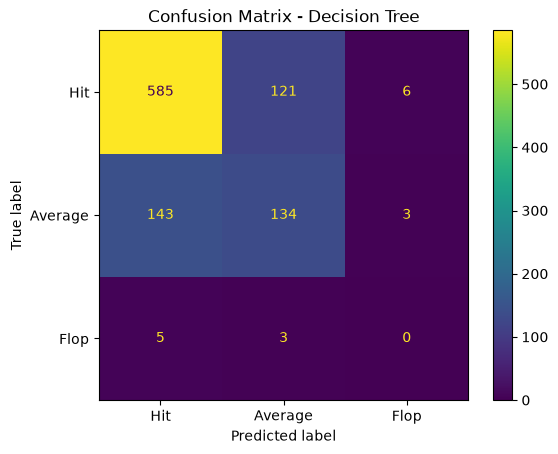

In [47]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Hit", "Average", "Flop"]
)

disp.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()

**Observation:** The Decision Tree Classifier correctly predicted 585 Hit movies and 134 Average movies. However, it failed to correctly predict any of the 8 Flop movies in the test dataset. Compared with Logistic Regression, the Decision Tree correctly identified more Average movies but fewer Hit movies. The inability to correctly identify the Flop category indicates that the severe class imbalance continues to affect minority-class prediction.

In [48]:
#Decision Tree Classification Report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

     average       0.52      0.48      0.50       280
        flop       0.00      0.00      0.00         8
         hit       0.80      0.82      0.81       712

    accuracy                           0.72      1000
   macro avg       0.44      0.43      0.44      1000
weighted avg       0.71      0.72      0.72      1000



**Observation:** The Decision Tree Classifier achieved an overall accuracy of approximately 71.9%. The model achieved an F1-score of 0.81 for Hit movies and 0.50 for Average movies. However, it failed to correctly identify the Flop category, resulting in an F1-score of 0.00 for Flop movies. The macro F1-score of 0.44 is considerably lower than the weighted F1-score of 0.72, indicating that class imbalance affects the overall evaluation of the model.

In [49]:
#Random Forest Classifier
#the Random Forest Classifier is used to predict whether a movie belongs to the Hit, Average, or Flop category.

from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf[:20]

array(['hit', 'average', 'hit', 'hit', 'hit', 'average', 'average', 'hit',
       'hit', 'hit', 'hit', 'hit', 'hit', 'hit', 'hit', 'hit', 'hit',
       'hit', 'hit', 'hit'], dtype=object)

In [51]:
#Random Forest Model Evaluation
#accuracy
rf_accuracy = accuracy_score(y_test,y_pred_rf)
print("RandomForestAccuracy:",rf_accuracy)

RandomForestAccuracy: 0.801


**Observation:** The Random Forest Classifier achieved an overall accuracy of 80.1% on the test dataset. This is higher than the accuracy obtained from Logistic Regression (75.6%) and Decision Tree (71.9%). However, since the target classes are imbalanced, the confusion matrix and classification report are also evaluated to understand the model's performance across Hit, Average, and Flop categories.

In [52]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test,y_pred_rf,labels=["hit","average","flop"])
                         

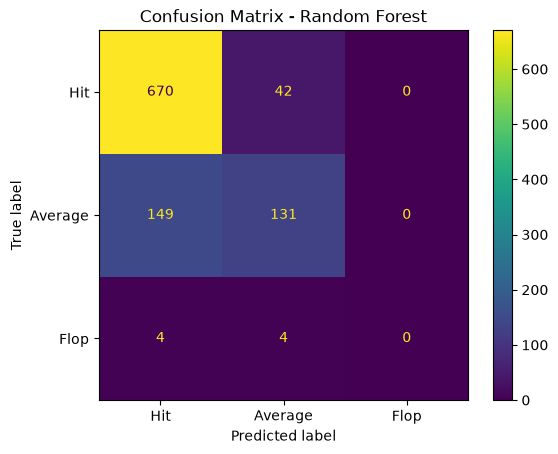

In [53]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Hit", "Average", "Flop"])

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Observation:** The Random Forest Classifier correctly predicted 670 Hit movies and 131 Average movies. However, it failed to correctly identify any of the 8 Flop movies in the test dataset. The model did not predict any observation as Flop. This indicates that although Random Forest achieved a relatively high overall accuracy of 80.1%, its performance is strongly influenced by the class imbalance in the dataset, particularly the very small number of Flop movies.

In [54]:
# Random Forest Classification Report

In [55]:
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

     average       0.74      0.47      0.57       280
        flop       0.00      0.00      0.00         8
         hit       0.81      0.94      0.87       712

    accuracy                           0.80      1000
   macro avg       0.52      0.47      0.48      1000
weighted avg       0.79      0.80      0.78      1000



**Observation:** The Random Forest Classifier achieved an overall accuracy of 80.1%. It performed strongly for the Hit category, with a recall of 0.94 and an F1-score of 0.87. For the Average category, the model achieved an F1-score of 0.57. However, the model did not predict any movies as Flop, resulting in precision, recall, and F1-score of 0.00 for the Flop category. This indicates that the severe class imbalance affects the model's ability to identify the minority Flop class.

In [ ]:
# Hyperparameter Tuning - Random Forest
#Import GridSearchCV


In [81]:
from sklearn.model_selection import GridSearchCV

In [83]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

rf_tuning_model = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_tuning_model,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [84]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Macro F1:
0.5460474675653463


In [91]:
best_rf_model = grid_search.best_estimator_

In [92]:
y_pred_tuned_rf = best_rf_model.predict(X_test)

In [93]:
tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)

In [94]:
print("Tuned Random Forest Accuracy:", tuned_rf_accuracy)

Tuned Random Forest Accuracy: 0.775


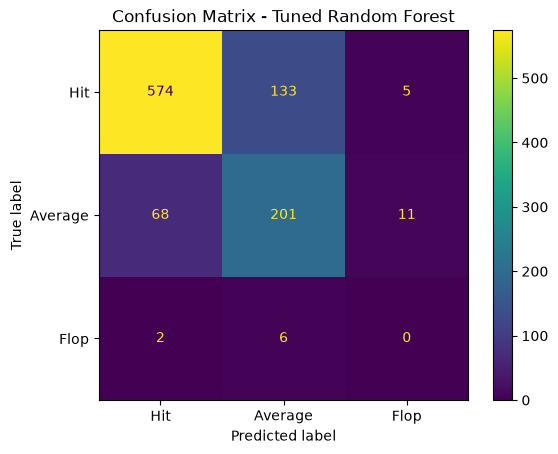

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["hit", "average", "flop"]

cm_tuned_rf = confusion_matrix(
    y_test,
    y_pred_tuned_rf,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_rf,
    display_labels=["Hit", "Average", "Flop"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

**Observation:** After hyperparameter tuning, the Random Forest accuracy decreased from 80.1% to 77.5%. However, the tuned model showed a significant improvement in identifying Average movies, correctly predicting 201 out of 280 compared with 131 out of 280 in the original Random Forest.

The number of correctly predicted Hit movies decreased from 670 to 574. The tuned model also began predicting some observations as Flop, but none of the 8 actual Flop movies were correctly classified.

Therefore, hyperparameter tuning improved the model's ability to identify the Average category but did not solve the problem of identifying the minority Flop category. The results demonstrate a trade-off between overall accuracy and class-level performance.

In [101]:
print(classification_report(
    y_test,
    y_pred_tuned_rf,
    zero_division=0
))

              precision    recall  f1-score   support

     average       0.59      0.72      0.65       280
        flop       0.00      0.00      0.00         8
         hit       0.89      0.81      0.85       712

    accuracy                           0.78      1000
   macro avg       0.49      0.51      0.50      1000
weighted avg       0.80      0.78      0.78      1000



In [100]:
#model comparison:

In [99]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        tuned_rf_accuracy
    ]
})

model_comparison


,Model,Accuracy
0,Logistic Regression,0.756
1,Decision Tree,0.719
2,Random Forest,0.801
3,Tuned Random Forest,0.775


The following key findings were observed during the project:

- The movie dataset was highly imbalanced. After data cleaning, there were 3,556 Hit movies, 1,401 Average movies, and only 41 Flop movies.
- Exploratory Data Analysis showed that IMDb scores were mostly concentrated between approximately 5 and 8.
- Hit movies had a higher median duration of approximately 107 minutes compared with 97 minutes for Average movies and 92 minutes for Flop movies.
- The median budget was approximately 20 million across all three success categories, indicating that median budget alone did not clearly separate Hit, Average, and Flop movies.
- Correlation analysis identified high correlation between some numerical variables, including actor_1_facebook_likes and cast_total_facebook_likes.
- Logistic Regression achieved 75.6% accuracy.
- Decision Tree achieved 71.9% accuracy.
- Random Forest achieved the highest overall accuracy of 80.1%.
- Hyperparameter tuning was performed on Random Forest using GridSearchCV with Macro F1 as the scoring metric.
- The Tuned Random Forest achieved 77.5% accuracy. Although its overall accuracy was lower, Average recall improved from 47% to 72% and Macro F1 improved from 0.48 to 0.50.
- The original Random Forest performed particularly well on the majority Hit category, whereas the tuned model provided a better balance between Hit and Average predictions.
- None of the evaluated models correctly identified the Flop category.
- The results demonstrate that overall accuracy alone is not sufficient when evaluating a highly imbalanced classification problem.

Project Limitations

• Severe class imbalance, especially the Flop category
• Only 33 Flops for training and 8 for testing
• No model correctly identified a Flop test case
• Hyperparameter tuning could not overcome the shortage of Flop examples
• Some variables contained extreme/skewed values
• Some predictors contain post-release information
• Current model should not be treated as a purely pre-release forecasting system

Conclusion

This project developed an end-to-end machine learning pipeline for classifying movies into Hit, Average, and Flop categories based on IMDb score ranges.

The project involved data cleaning, exploratory data analysis, categorical encoding, multicollinearity analysis, train-test splitting, feature scaling, model building, evaluation, and hyperparameter tuning.

Three classification algorithms were initially evaluated: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression achieved 75.6% accuracy, Decision Tree achieved 71.9%, and Random Forest achieved the highest overall accuracy of 80.1%.

Random Forest was further optimized using GridSearchCV. The Tuned Random Forest achieved 77.5% accuracy compared with 80.1% for the original model. However, Average-class recall improved from 47% to 72%, while Macro F1 improved from 0.48 to 0.50. This demonstrated that higher overall accuracy does not necessarily indicate better performance across every class.

Despite tuning, the model was unable to correctly identify the Flop category. The primary reason was the severe class imbalance and the very small number of Flop observations available for training.

Overall, the project demonstrates the complete machine learning classification workflow while also highlighting the importance of evaluating class-level performance rather than relying only on accuracy. Future improvements should focus on obtaining more balanced data and improving minority-class prediction.